In [87]:
import seaborn as sns
import pandas as pd
import json
from pathlib import Path
from matplotlib.patches import Ellipse
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import ListedColormap

In [88]:
result_path = Path("../results/downstream_task")
bias_type = "less_positive_class"
less_bias_strength = "0.1"
method = "fw-mrs-temperature-comparison"
data_set_name = "folktables_income"

In [89]:
dropped_samples_file_name = result_path / data_set_name / bias_type / less_bias_strength / method / "validation" / "dropped_samples_individual_val_dict.json"
with open(dropped_samples_file_name) as file:
        dropped_samples = json.load(file)
        dropped_samples = pd.DataFrame(dropped_samples)
auroc_file_name = result_path / data_set_name / bias_type / less_bias_strength / method / "validation" / "auroc_individual_val_dict.json"
with open(auroc_file_name) as file:
        aurocs = json.load(file)
        aurocs = pd.DataFrame(aurocs)

In [90]:
dropped_samples

,0.5,0.25,0.1,0.05,0.025,0.01,0.005,0.0025,0.001,0.0
0,200,180,185,185,180,150,140,120,110,210
1,160,175,150,150,125,115,110,100,60,140
2,160,155,165,145,150,115,110,85,95,180
3,175,165,165,165,135,105,100,80,65,175
4,100,90,115,105,70,75,65,65,65,115
5,210,190,190,185,165,165,135,155,145,210
6,185,175,170,165,165,145,150,140,135,195
7,170,175,165,140,145,115,140,125,90,165
8,180,185,160,165,150,125,90,95,80,170
9,210,225,225,205,220,190,165,170,175,240


In [91]:
aurocs

,0.5,0.25,0.1,0.05,0.025,0.01,0.005,0.0025,0.001,0.0
0,0.833599,0.833556,0.831408,0.823270,0.810630,0.783523,0.770150,0.748993,0.727184,0.837557
1,0.840739,0.839229,0.836545,0.834247,0.825504,0.801381,0.784943,0.747247,0.712387,0.839480
2,0.825141,0.824690,0.824983,0.816620,0.799444,0.771423,0.767844,0.664277,0.695302,0.826371
3,0.836932,0.838036,0.832934,0.826510,0.815384,0.790499,0.777175,0.748050,0.713374,0.842781
4,0.836580,0.836159,0.825138,0.827216,0.818286,0.788096,0.766872,0.731648,0.707838,0.836715
5,0.852951,0.852641,0.856489,0.850325,0.842118,0.813631,0.800028,0.761768,0.728298,0.856995
6,0.848369,0.843432,0.837666,0.839159,0.816122,0.790169,0.782218,0.751349,0.701083,0.843814
7,0.833172,0.834465,0.830691,0.804873,0.812640,0.789230,0.782069,0.768598,0.674469,0.836083
8,0.841031,0.844752,0.838882,0.828649,0.801528,0.775697,0.766772,0.745173,0.697742,0.843504
9,0.848853,0.850968,0.843666,0.838400,0.820318,0.789377,0.773919,0.728094,0.702178,0.851636


In [92]:
temperatures = dropped_samples.drop(columns=["0.0"]).keys().astype(float)
temperatures  = temperatures.insert(0, 0.0)

temperature_labels = temperatures.astype(str).array
temperature_labels[0] = "MRS"
temperature_labels[1] = "0.5000"
temperature_labels[2] = "0.2500"
temperature_labels[3] = "0.1000"
temperature_labels[4] = "0.0500"
temperature_labels[5] = "0.0250"
temperature_labels[6] = "0.0100"
temperature_labels[7] = "0.0050"
temperature_labels[9] = "0.0010"
temperature_labels

<NumpyExtensionArray>
[   'MRS', '0.5000', '0.2500', '0.1000', '0.0500', '0.0250', '0.0100',
 '0.0050', '0.0025', '0.0010']
Length: 10, dtype: object

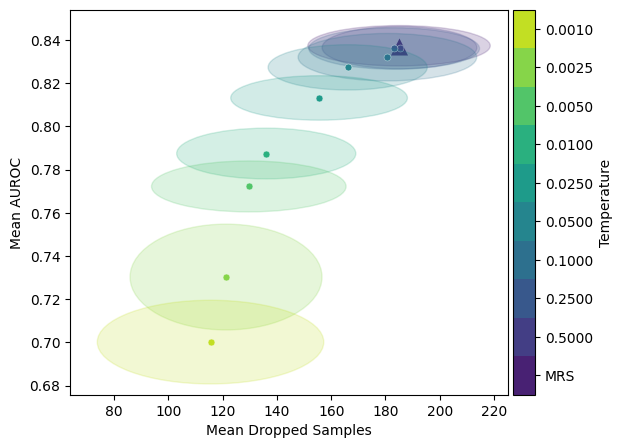

In [93]:
palette = sns.color_palette("viridis", n_colors=len(temperatures))
cmap = ListedColormap(palette)
fig = plt.figure(figsize=(6,5))
mrs_value = 0.0
min_x = np.inf
min_y = np.inf

for i, (key, dropped_value) in enumerate(dropped_samples[temperatures.astype(str)].items()):
    auroc_value = aurocs[key]
    if float(key) == mrs_value:
        marker= "^"
        size= 200
    else: 
        marker = "o"
        size= 25
        
    color = cmap(i)
    ax = sns.scatterplot(x=[dropped_value.mean()], y=[auroc_value.mean()], label=key, alpha=1, color=color, marker=marker,
                         s=size,)
    ellipse = Ellipse((dropped_value.mean(), auroc_value.mean()),
                       width=2*dropped_value.std(), height=2*auroc_value.std(), alpha=0.2,
                       color=color)
    min_x = min(min_x, dropped_value.mean() - dropped_value.std())
    min_y = min(min_y, auroc_value.mean() - auroc_value.std())
    ax.add_patch(ellipse)

plt.gca().legend_.remove()

divider = make_axes_locatable(plt.gca())
ax_cb = divider.new_horizontal(size="5%", pad=0.05)
fig.add_axes(ax_cb)
cbar = matplotlib.colorbar.ColorbarBase(ax_cb, cmap=cmap,
                                orientation='vertical')
cbar.set_label('Temperature')
cbar.set_ticks(np.linspace(0.05,0.95,10))
cbar.set_ticklabels(temperature_labels)
ax.set_xlim(min_x - 10)
ax.set_ylim(min_y - 0.005)

_= ax.set(xlabel="Mean Dropped Samples", ylabel="Mean AUROC")
plt.savefig("diagrams/temperature_comparison_fixed.pdf", bbox_inches="tight")

In [94]:
dropped_samples_file_name = result_path / data_set_name / bias_type / less_bias_strength / method / "validation" / "dropped_samples_val_dict.json"
with open(dropped_samples_file_name) as file:
        dropped_samples = json.load(file)
        dropped_samples = pd.DataFrame(dropped_samples)
auroc_file_name = result_path / data_set_name / bias_type / less_bias_strength / method / "validation" / "auroc_val_dict.json"
with open(auroc_file_name) as file:
        aurocs = json.load(file)
        aurocs = pd.DataFrame(aurocs)

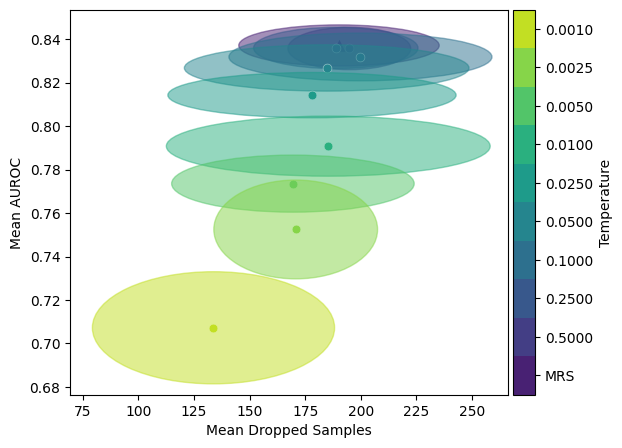

In [95]:
palette = sns.color_palette("viridis", n_colors=len(temperatures))
cmap = ListedColormap(palette)
fig = plt.figure(figsize=(6,5))
mrs_value = 0.0
min_x = np.inf
min_y = np.inf

for i, (key, dropped_value) in enumerate(dropped_samples[temperatures.astype(str)].items()):
    auroc_value = aurocs[key]
    if float(key) == mrs_value:
        marker= "^"
        size= 100
    else: 
        marker = "o"
        size= 40
        
    color = cmap(i)
    ax = sns.scatterplot(x=[dropped_value.mean()], y=[auroc_value.mean()], label=key, alpha=1, color=color, marker=marker,
                         s=size, )
    ellipse = Ellipse((dropped_value.mean(), auroc_value.mean()),
                       width=2*dropped_value.std(), height=2*auroc_value.std(), alpha=0.5,
                       color=color)
    min_x = min(min_x, dropped_value.mean() - dropped_value.std())
    min_y = min(min_y, auroc_value.mean() - auroc_value.std())
    ax.add_patch(ellipse)

plt.gca().legend_.remove()

divider = make_axes_locatable(plt.gca())
ax_cb = divider.new_horizontal(size="5%", pad=0.05)
fig.add_axes(ax_cb)
cbar = matplotlib.colorbar.ColorbarBase(ax_cb, cmap=cmap,
                                orientation='vertical')
cbar.set_label('Temperature')
cbar.set_ticks(np.linspace(0.05,0.95,10))

cbar.set_ticklabels(temperature_labels)
ax.set_xlim(min_x - 10)
ax.set_ylim(min_y - 0.005)

_= ax.set(xlabel="Mean Dropped Samples", ylabel="Mean AUROC")
plt.savefig("diagrams/temperature_comparison_optimized.pdf", bbox_inches="tight")